# 03 — Reproduce CellNEST graph construction

This notebook reproduces the **graph-construction stage** of
[CellNEST](https://github.com/schwartzlab-methods/CellNEST) (Fatema *et al.*, *Nature
Methods* 2025) using our clean-room package [`src/cellnest_graph`](../src/cellnest_graph).

It **stops at graph construction** — no GAT training, no Deep Graph Infomax, no higher-order
lifting. The output is a backend-neutral graph ready to be lifted to a TopoNetX cell complex
in the next milestone.

See [`docs/cellnest_graph_reference.md`](../docs/cellnest_graph_reference.md) for the exact
trace of the original CellNEST code.

## 1. The CellNEST graph definition (plain English)

**Node** = one spatial cell/spot. Node feature = its (quantile-normalised) gene-expression
vector, or a reduced representation (e.g. one-hot cell type). We keep cell id, coordinates,
sample id and cell type when available.

**Directed typed edge `i → j`** for a ligand–receptor pair `(l, r)` exists when:

1. cell `i` expresses ligand `l` (active);
2. cell `j` expresses receptor `r` (active);
3. `distance(i, j) ≤ d_max` (spatial neighbourhood);
4. `(l, r)` is in the supplied LR database.

Each `(l, r)` pair is a **distinct relation type**. Edge attributes: source/target,
ligand, receptor, relation id, Euclidean distance, ligand expression in the sender, receptor
expression in the receiver, co-expression score `= expr_l(i)·expr_r(j)`, a distance weight,
and an optional distance-modulated score.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cellnest_graph import build_cellnest_graph
from cellnest_graph.synthetic import toy_dataset
print("imports OK")

## 2. Run the deterministic synthetic example

Six cells; two ligands, two receptors; three LR relations. Cells 4 and 5 are placed far away
so they are spatially isolated at `d_max = 1.5`. The expected directed edges are known in
advance (encoded in `toy_dataset().expected_edges`).

In [4]:
ds = toy_dataset()
graph = build_cellnest_graph(
    ds.adata, ds.lr_pairs,
    d_max=ds.d_max,
    gene_activity_percentile=None,   # toy example uses absolute thresholds for determinism
    block_autocrine=True,
)
print("nodes:", graph.n_nodes, " edges:", graph.n_edges, " relations:", graph.n_relations)

# check we reproduced the hand-derived edge set exactly
got = {(int(r.source), int(r.target), r.ligand, r.receptor, int(r.relation_id))
       for r in graph.edge_table.itertuples(index=False)}
exp = {(s,t,l,rc,rid) for (s,t,l,rc,rid,_d,_c) in ds.expected_edges}
print("edge set matches expected:", got == exp)

nodes: 6  edges: 7  relations: 3
edge set matches expected: True


## 3. Visualise cells and directed typed edges

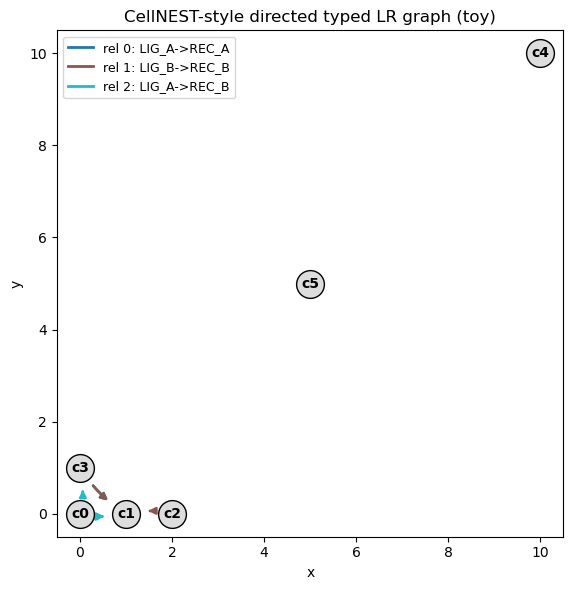

In [5]:
coords = graph.coordinates
rel_colors = plt.cm.tab10(np.linspace(0, 1, max(graph.n_relations, 1)))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(coords[:, 0], coords[:, 1], s=400, c="#dddddd", edgecolors="k", zorder=3)
for i, (x, y) in enumerate(coords):
    ax.annotate(f"c{i}", (x, y), ha="center", va="center", zorder=4, fontweight="bold")

for r in graph.edge_table.itertuples(index=False):
    s, t = int(r.source), int(r.target)
    if s == t:
        continue
    x0, y0 = coords[s]; x1, y1 = coords[t]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=rel_colors[int(r.relation_id)],
                                lw=1.8, shrinkA=16, shrinkB=16,
                                connectionstyle="arc3,rad=0.12"), zorder=2)

handles = [plt.Line2D([0], [0], color=rel_colors[i], lw=2,
                      label=f"rel {i}: {row.ligand}->{row.receptor}")
           for i, row in graph.relation_table.iterrows()]
ax.legend(handles=handles, loc="upper left", fontsize=9)
ax.set_title("CellNEST-style directed typed LR graph (toy)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 4. Node, edge and relation tables

In [6]:
try:
    from IPython.display import display
except Exception:            # running outside Jupyter
    display = lambda df: print(df.to_string(index=False))
print("Relation mapping:"); display(graph.relation_table)
print("\nNodes:");          display(graph.node_table)
print("\nEdges:");          display(graph.edge_table)

Relation mapping:


,relation_id,ligand,receptor,is_contact
0,0,LIG_A,REC_A,False
1,1,LIG_B,REC_B,False
2,2,LIG_A,REC_B,False



Nodes:


,node_index,cell_id,x,y
0,0,cell0,0.0,0.0
1,1,cell1,1.0,0.0
2,2,cell2,2.0,0.0
3,3,cell3,0.0,1.0
4,4,cell4,10.0,10.0
5,5,cell5,5.0,5.0



Edges:


,source,target,ligand,receptor,relation_id,distance,ligand_expression,receptor_expression,coexpression_score,distance_weight,distance_modulated_score
0,0,1,LIG_A,REC_A,0,1.000000,5.0,3.0,15.0,1.0,15.0
1,0,1,LIG_A,REC_B,2,1.000000,5.0,4.0,20.0,1.0,20.0
2,2,1,LIG_B,REC_B,1,1.000000,6.0,4.0,24.0,1.0,24.0
3,3,1,LIG_A,REC_A,0,1.414214,1.0,3.0,3.0,0.0,0.0
4,3,1,LIG_A,REC_B,2,1.414214,1.0,4.0,4.0,0.0,0.0
5,3,1,LIG_B,REC_B,1,1.414214,1.0,4.0,4.0,0.0,0.0
6,0,3,LIG_A,REC_B,2,1.000000,5.0,2.0,10.0,1.0,10.0


## 5. Graph statistics

In [7]:
for k, v in graph.stats().items():
    print(f"{k:28s}: {v}")

print("\nedge feature columns:", graph.edge_feature_names)
print("edge_index shape:", graph.edge_index.shape)
print("edge_features shape:", graph.edge_features.shape)
print("node_features shape:", graph.node_features.shape)

n_nodes                     : 6
n_edges                     : 7
n_relation_types_defined    : 3
n_relation_types_used       : 3
n_self_loops                : 0
n_isolated_nodes            : 2
mean_out_degree             : 1.1666666666666667
max_out_degree              : 3
mean_distance               : 1.1775200981598977
max_distance                : 1.4142135623730951
mean_coexpression           : 11.428571428571429

edge feature columns: ('distance_weight', 'coexpression_score', 'distance', 'ligand_expression', 'receptor_expression', 'distance_modulated_score')
edge_index shape: (2, 7)
edge_features shape: (7, 6)
node_features shape: (6, 5)


## 6. (Optional) small real AnnData subset

This block runs **only if** a local `.h5ad` already exists — it never downloads the full
dataset. It uses `--max-cells`-style capping and a single sample so it stays a smoke test.
Edit `H5AD` / `SAMPLE_KEY` to point at your file.

In [ ]:
from pathlib import Path
from cellnest_graph import load_lr_pairs_csv

H5AD = os.environ.get("ST_DATA")  # or set a path string here
candidates = sorted(Path("../data").glob("*.h5ad"))
if H5AD is None and candidates:
    H5AD = str(candidates[0])

if H5AD and os.path.exists(H5AD):
    import scanpy as sc
    adata = sc.read_h5ad(H5AD)
    print("loaded", H5AD, adata.shape)
    lr = load_lr_pairs_csv("../data/ligand_receptor_pairs.csv")
    # cap to a small subset for the smoke test
    sub = adata[:2000].copy()
    g = build_cellnest_graph(sub, lr, spatial_key="spatial", d_max=30.0,
                             gene_activity_percentile=98.0, max_cells=2000,
                             block_autocrine=True)   # no autocrine (i -> i) edges
    for k, v in g.stats().items():
        print(f"{k:28s}: {v}")
else:
    print("No local .h5ad found — skipping the real-data demo (this is expected).")
    print("See data/datasets.md to download a dataset into data/.")

## 7. Next step (do **not** run here)

The neutral `CellNestGraph` is designed to be lifted to a higher-order structure:

```
graph  ->  TopoNetX cell / simplicial complex  (0-cells = nodes, 1-cells = edges, 2-cells = filled motifs)
```

That lifting is the **next milestone** and is intentionally not started in this notebook.
`graph.to_networkx()` and `src/topo_utils.py::graph_to_simplices` are the natural entry
points for it.

## 8 run aon ral data


In [20]:
from pathlib import Path
from cellnest_graph import load_lr_pairs_csv

H5AD = os.environ.get("ST_DATA")  # or set a path string here
candidates = sorted(Path("../data").glob("*.h5ad"))
if H5AD is None and candidates:
    H5AD = str(candidates[0])

if H5AD and os.path.exists(H5AD):
    import scanpy as sc
    adata = sc.read_h5ad(H5AD)
    print("loaded", H5AD, adata.shape)
    lr = load_lr_pairs_csv("../data/ligand_receptor_pairs.csv")
    # cap to a small subset for the smoke test

loaded ../data/GSE294965_processed_data.h5ad (3218210, 480)


In [28]:
adata

AnnData object with n_obs × n_vars = 3218210 × 480
    obs: 'x', 'y', 'z', 'cluster', 'n_transcripts', 'density', 'elongation', 'area', 'avg_confidence', 'avg_assignment_confidence', 'max_cluster_frac', 'lifespan', 'x_centroid', 'y_centroid', 'cell_area', 'Slide_ID', 'batch', 'Patient_Sample_ID', 'Disease', 'n_genes', 'celltype_l1', 'celltype_l1_codes', 'celltype_l1_prob', 'Biopsy_ID', 'sample', 'label', 'nichepca_domain', 'nichepca_domain_tuned', 'nichepca_glom_no', 'glom_ID', 'polygon_flags', 'is_in_polygon', 'is_in_glom', 'is_in_periglom', 'Slide_num'
    var: 'gene_ids', 'feature_types'
    uns: 'celltype_l1_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'

In [40]:
sub=adata[adata.obs['Biopsy_ID'] =='0018775 - X4']
sub

View of AnnData object with n_obs × n_vars = 29161 × 480
    obs: 'x', 'y', 'z', 'cluster', 'n_transcripts', 'density', 'elongation', 'area', 'avg_confidence', 'avg_assignment_confidence', 'max_cluster_frac', 'lifespan', 'x_centroid', 'y_centroid', 'cell_area', 'Slide_ID', 'batch', 'Patient_Sample_ID', 'Disease', 'n_genes', 'celltype_l1', 'celltype_l1_codes', 'celltype_l1_prob', 'Biopsy_ID', 'sample', 'label', 'nichepca_domain', 'nichepca_domain_tuned', 'nichepca_glom_no', 'glom_ID', 'polygon_flags', 'is_in_polygon', 'is_in_glom', 'is_in_periglom', 'Slide_num'
    var: 'gene_ids', 'feature_types'
    uns: 'celltype_l1_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'

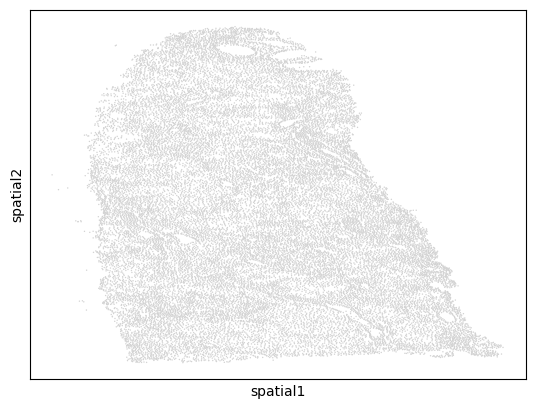

In [87]:
sc.pl.embedding(sub, basis='spatial')

In [100]:
g = build_cellnest_graph(sub, lr, spatial_key="spatial", d_max=50.0,
                         gene_activity_percentile=80.0, max_cells=200000,
                         block_autocrine=True)   # paracrine only: drop autocrine i -> i edges
for k, v in g.stats().items():
    print(f"{k:28s}: {v}")
assert g.stats()["n_self_loops"] == 0, "autocrine edges should be gone"

n_nodes                     : 29161
n_edges                     : 315794
n_relation_types_defined    : 54
n_relation_types_used       : 54
n_self_loops                : 0
n_isolated_nodes            : 12430
mean_out_degree             : 10.829326840643326
max_out_degree              : 194
mean_distance               : 32.888656117148116
max_distance                : 49.9999020215892
mean_coexpression           : 0.30670440785747743


## 9. Visualize the directed LR graph (NetworkX)

In [101]:
import networkx as nx

# Convert CellNestGraph to a directed NetworkX MultiDiGraph
G = g.to_networkx()
print(f"NetworkX graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"self-loops (autocrine): {nx.number_of_selfloops(G)}")

# Relation colours (tab20 has 20 distinct hues; tab10 aliases badly across ~54 relations)
rel_colors = plt.cm.tab20(np.linspace(0, 1, max(g.n_relations, 1)))

# Relation-type counts for logging
rel_type_counts = {}
for _, _, key in G.edges(keys=True):
    rel_type_counts[int(key)] = rel_type_counts.get(int(key), 0) + 1

print(f"Relation types in use: {rel_type_counts}")
print(f"Relation type info:\n{g.relation_table}")

NetworkX graph: 29161 nodes, 315794 edges
self-loops (autocrine): 0
Relation types in use: {47: 17583, 3: 1330, 44: 2939, 36: 17851, 48: 14320, 5: 2234, 28: 199, 38: 8049, 45: 1174, 46: 817, 11: 206, 39: 2687, 1: 81548, 41: 21548, 43: 57479, 42: 11186, 26: 1632, 9: 1824, 7: 159, 52: 1216, 20: 240, 33: 2561, 16: 141, 51: 2971, 21: 88, 8: 56, 19: 3385, 0: 25284, 32: 3175, 53: 3351, 6: 4958, 22: 1007, 2: 3502, 23: 79, 4: 3053, 24: 7373, 17: 291, 18: 87, 40: 1451, 50: 2447, 49: 1129, 34: 290, 35: 156, 29: 119, 37: 1371, 27: 273, 25: 142, 12: 188, 30: 219, 10: 168, 15: 86, 13: 68, 14: 35, 31: 69}
Relation type info:
    relation_id   ligand receptor  is_contact
0             0     CDH2     CDH2       False
1             1     CDH6     CDH6       False
2             2  CEACAM1    CD209       False
3             3  CEACAM1     SELE       False
4             4    ICAM1    ITGAL       False
5             5     JAM2     JAM3       False
6             6     JAM3     JAM3       False
7            

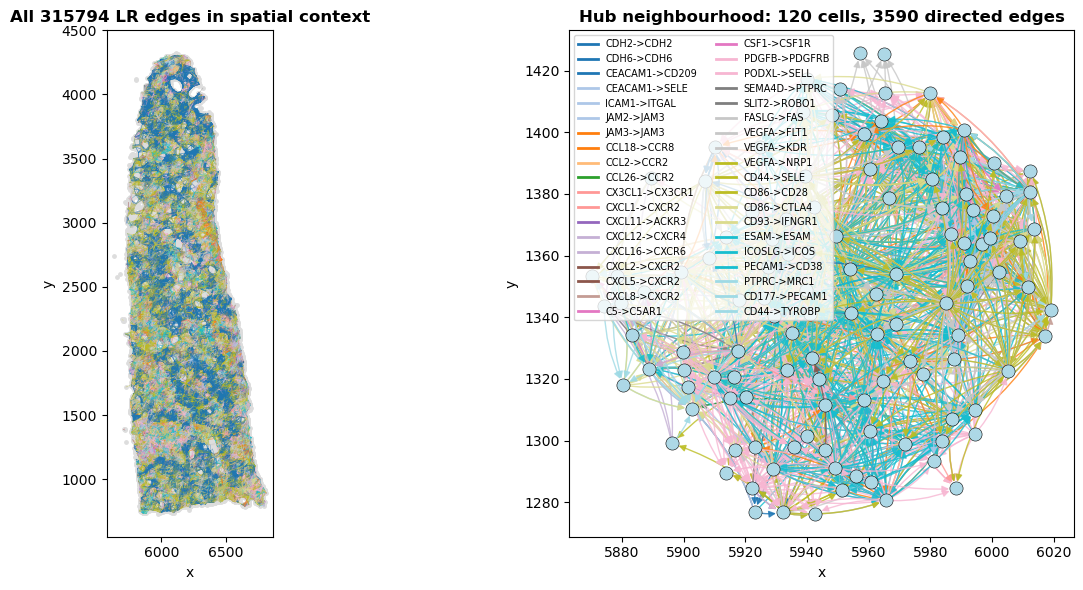

In [102]:
# Directed graph drawn on TRUE SPATIAL COORDINATES only.
# No force-directed / spring / circular layout anywhere: node positions are the measured
# (x, y) of each cell, so drawing is O(nodes + edges) and stays physically interpretable.
import networkx as nx

if 'G' not in globals():
    G = g.to_networkx()
if 'rel_colors' not in globals():
    rel_colors = plt.cm.tab20(np.linspace(0, 1, max(g.n_relations, 1)))

# Pick a subgraph that actually has edges: the highest-degree node and its neighbours.
# (Taking the first N node ids would mostly pick isolated cells.)
connected = [n for n in G.nodes() if G.degree(n) > 0]
hub = max(connected, key=lambda n: G.degree(n))
core = {hub} | set(G.successors(hub)) | set(G.predecessors(hub))
for n in list(core):                      # one more hop, capped
    core |= set(G.successors(n)) | set(G.predecessors(n))
    if len(core) > 120:
        break
H = G.subgraph(list(core)[:120]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pos = {i: (g.coordinates[i, 0], g.coordinates[i, 1]) for i in G.nodes()}

# Left: whole section, edges only (cheap scatter + line segments)
ax = axes[0]
ax.scatter(g.coordinates[:, 0], g.coordinates[:, 1], s=6, c="#dddddd", zorder=1)
for k in range(g.n_edges):
    s, t = int(g.edge_index[0, k]), int(g.edge_index[1, k])
    x0, y0 = pos[s]; x1, y1 = pos[t]
    ax.plot([x0, x1], [y0, y1], color=rel_colors[int(g.edge_relation_id[k])],
            lw=0.4, alpha=0.5, zorder=2)
ax.set_title(f"All {g.n_edges} LR edges in spatial context", fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")

# Right: zoom on the hub neighbourhood, with arrow heads to show direction
ax = axes[1]
sub_xy = np.array([pos[n] for n in H.nodes()])
ax.scatter(sub_xy[:, 0], sub_xy[:, 1], s=90, c="lightblue", edgecolors="k",
           linewidths=0.4, zorder=3)
for (u, v, key) in H.edges(keys=True):
    x0, y0 = pos[u]; x1, y1 = pos[v]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=rel_colors[int(key)],
                                lw=1.0, alpha=0.8, shrinkA=5, shrinkB=5,
                                connectionstyle="arc3,rad=0.12"), zorder=2)
ax.set_title(f"Hub neighbourhood: {H.number_of_nodes()} cells, "
             f"{H.number_of_edges()} directed edges", fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")

# Legend: only the relation types actually present in the zoom, otherwise 54 entries drown it
used = sorted({int(k) for _, _, k in H.edges(keys=True)})
handles = [plt.Line2D([0], [0], color=rel_colors[i], lw=2,
                      label=f"{g.relation_table.iloc[i].ligand}->{g.relation_table.iloc[i].receptor}")
           for i in used]
ax.legend(handles=handles, loc="upper left", fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

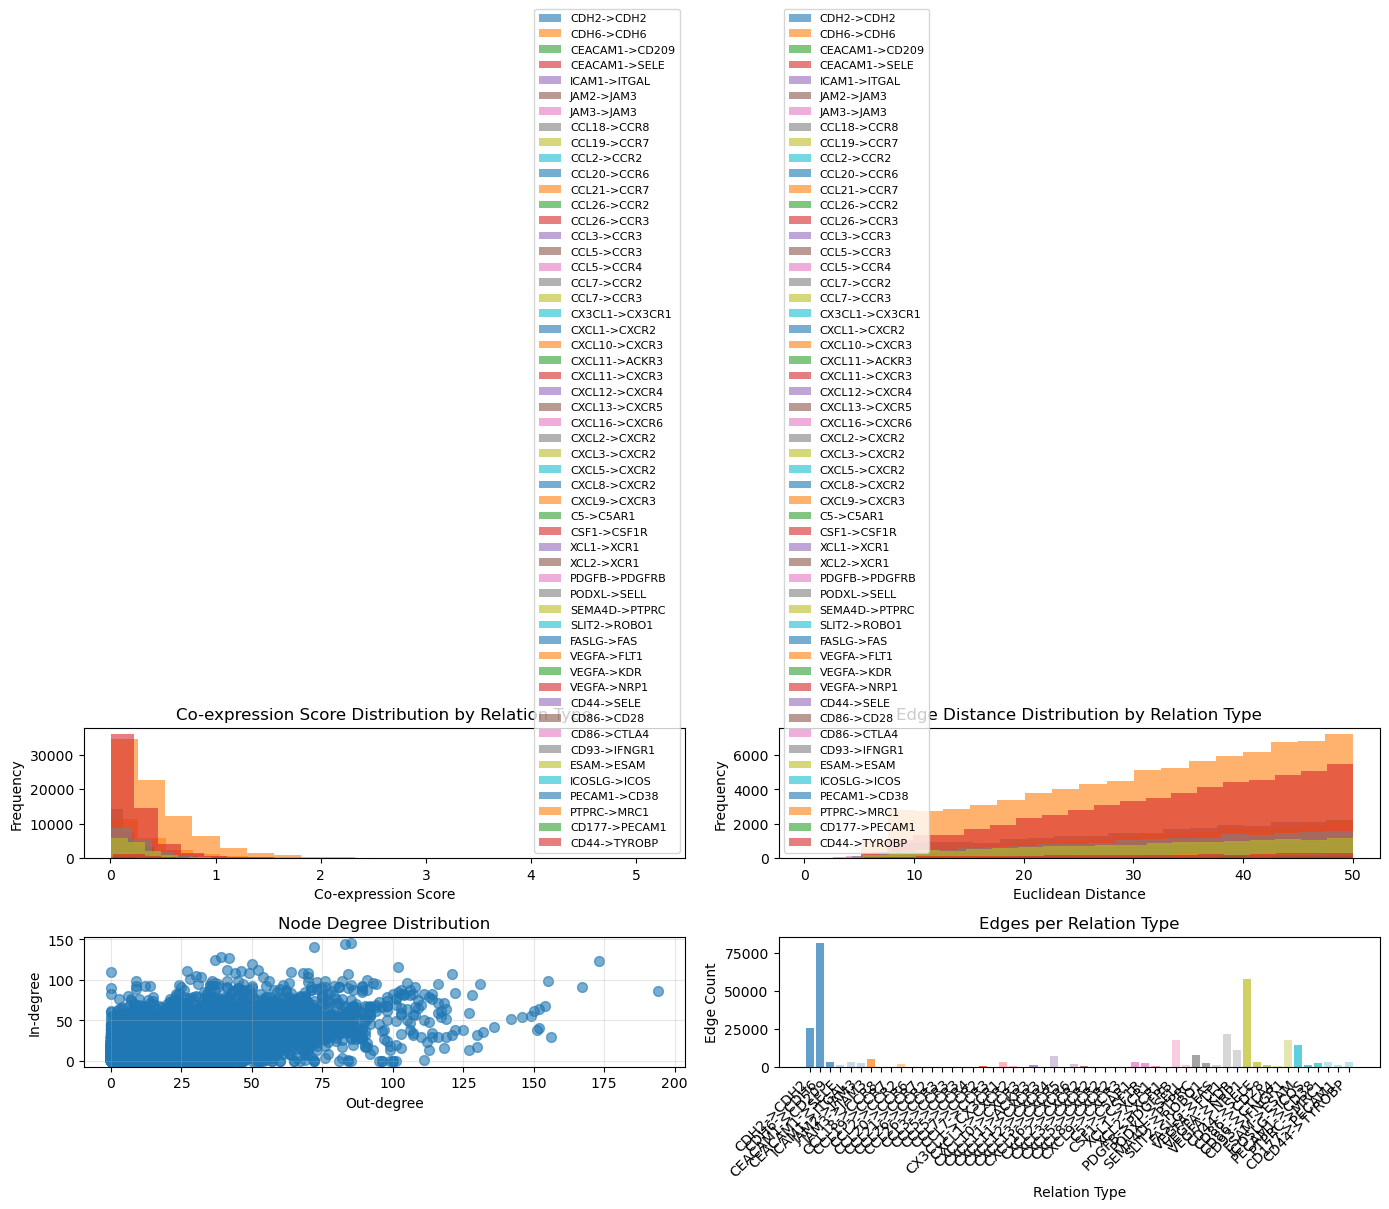

In [103]:
# Edge statistics visualization
import networkx as nx

# Make the cell self-contained if run out of order
if 'G' not in globals():
    G = g.to_networkx()
if 'rel_colors' not in globals():
    rel_colors = plt.cm.tab10(np.linspace(0, 1, max(g.n_relations, 1)))
if 'rel_type_counts' not in globals():
    rel_type_counts = {}
    for _, _, key in G.edges(keys=True):
        rel_type_counts[int(key)] = rel_type_counts.get(int(key), 0) + 1

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of edge co-expression scores by relation type
ax = axes[0, 0]
for rel_id in range(g.n_relations):
    mask = g.edge_relation_id == rel_id
    coexp = g.edge_feature("coexpression_score")[mask]
    if coexp.size > 0:
        lig, rec = g.relation_table.iloc[rel_id][["ligand", "receptor"]]
        ax.hist(coexp, bins=20, alpha=0.6, label=f"{lig}->{rec}")
ax.set_xlabel("Co-expression Score"); ax.set_ylabel("Frequency")
ax.set_title("Co-expression Score Distribution by Relation Type")
ax.legend(fontsize=8)

# 2. Distribution of edge distances by relation type
ax = axes[0, 1]
for rel_id in range(g.n_relations):
    mask = g.edge_relation_id == rel_id
    dist = g.edge_feature("distance")[mask]
    if dist.size > 0:
        lig, rec = g.relation_table.iloc[rel_id][["ligand", "receptor"]]
        ax.hist(dist, bins=20, alpha=0.6, label=f"{lig}->{rec}")
ax.set_xlabel("Euclidean Distance"); ax.set_ylabel("Frequency")
ax.set_title("Edge Distance Distribution by Relation Type")
ax.legend(fontsize=8)

# 3. Node in/out degree distribution
ax = axes[1, 0]
in_deg = [G.in_degree(n) for n in G.nodes()]
out_deg = [G.out_degree(n) for n in G.nodes()]
ax.scatter(out_deg, in_deg, alpha=0.6, s=50)
ax.set_xlabel("Out-degree"); ax.set_ylabel("In-degree")
ax.set_title("Node Degree Distribution")
ax.grid(True, alpha=0.3)

# 4. Edge count by relation type
ax = axes[1, 1]
rel_names = [f"{row.ligand}->{row.receptor}" for _, row in g.relation_table.iterrows()]
edge_counts = [rel_type_counts.get(i, 0) for i in range(g.n_relations)]
colors_bar = rel_colors[:g.n_relations]
ax.bar(range(g.n_relations), edge_counts, color=colors_bar, alpha=0.7)
ax.set_xlabel("Relation Type"); ax.set_ylabel("Edge Count")
ax.set_title("Edges per Relation Type")
ax.set_xticks(range(g.n_relations))
ax.set_xticklabels(rel_names, rotation=45, ha="right")

plt.tight_layout()
plt.show()

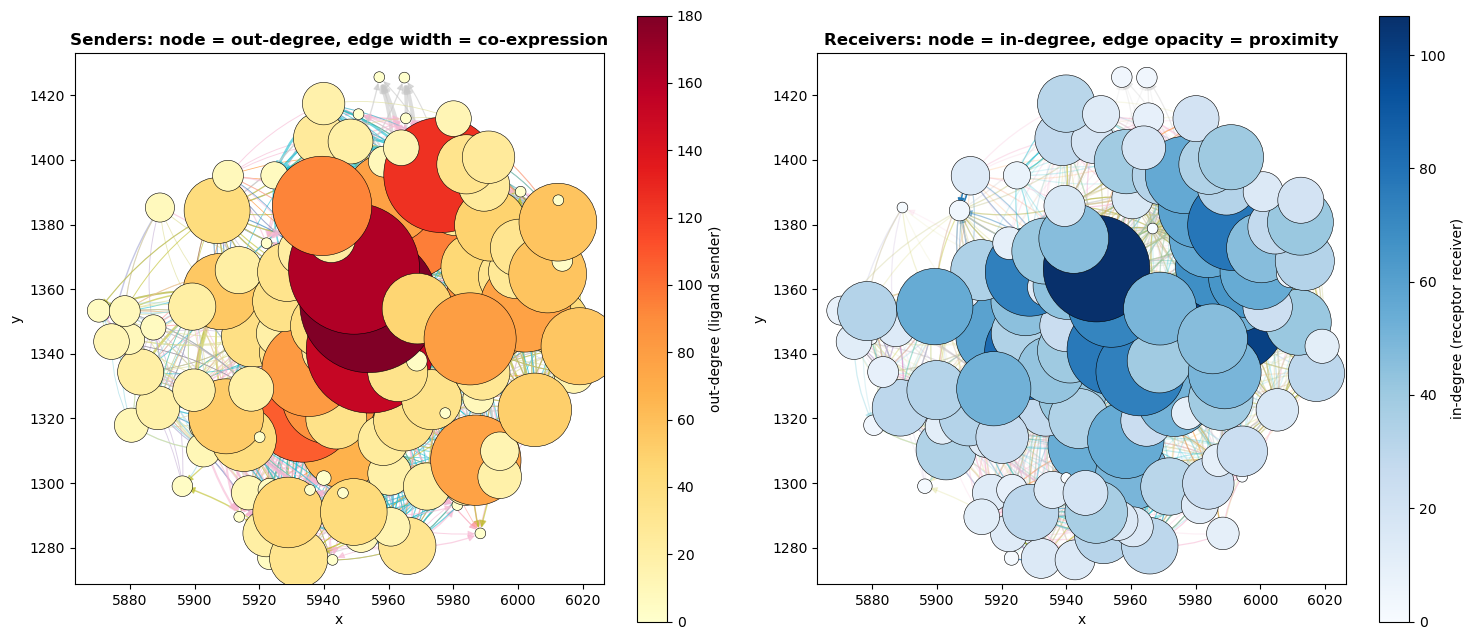

In [104]:
# Attributed spatial view: node size/colour from degree, edge width from co-expression.
# Again spatial coordinates only — no layout algorithm is run.
import networkx as nx

if 'G' not in globals():
    G = g.to_networkx()
if 'rel_colors' not in globals():
    rel_colors = plt.cm.tab20(np.linspace(0, 1, max(g.n_relations, 1)))
if 'H' not in globals():
    connected = [n for n in G.nodes() if G.degree(n) > 0]
    hub = max(connected, key=lambda n: G.degree(n))
    core = {hub} | set(G.successors(hub)) | set(G.predecessors(hub))
    H = G.subgraph(list(core)[:120]).copy()

pos = {i: (g.coordinates[i, 0], g.coordinates[i, 1]) for i in G.nodes()}
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# Left: out-degree (how much a cell signals out), edge width by co-expression strength
ax = axes[0]
xy = np.array([pos[n] for n in H.nodes()])
out_deg = np.array([H.out_degree(n) for n in H.nodes()])
sizes = np.maximum(60, out_deg * 55)
sc_out = ax.scatter(xy[:, 0], xy[:, 1], c=out_deg, s=sizes, cmap="YlOrRd",
                    edgecolors="k", linewidths=0.4, zorder=3)
plt.colorbar(sc_out, ax=ax, label="out-degree (ligand sender)")

coexp_max = max((d.get("coexpression_score", 1.0)
                 for _, _, _, d in H.edges(keys=True, data=True)), default=1.0)
for (u, v, key, data) in H.edges(keys=True, data=True):
    x0, y0 = pos[u]; x1, y1 = pos[v]
    w = 0.5 + (float(data.get("coexpression_score", 0.0)) / coexp_max) * 2.5 if coexp_max > 0 else 0.5
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=rel_colors[int(key)],
                                lw=w, alpha=0.6, shrinkA=4, shrinkB=4,
                                connectionstyle="arc3,rad=0.12"), zorder=2)
ax.set_title("Senders: node = out-degree, edge width = co-expression", fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")

# Right: in-degree (how much a cell receives), edge opacity by proximity
ax = axes[1]
in_deg = np.array([H.in_degree(n) for n in H.nodes()])
sizes_in = np.maximum(60, in_deg * 55)
sc_in = ax.scatter(xy[:, 0], xy[:, 1], c=in_deg, s=sizes_in, cmap="Blues",
                   edgecolors="k", linewidths=0.4, zorder=3)
plt.colorbar(sc_in, ax=ax, label="in-degree (receptor receiver)")

dist_max = max((d.get("distance", 1.0)
                for _, _, _, d in H.edges(keys=True, data=True)), default=1.0)
for (u, v, key, data) in H.edges(keys=True, data=True):
    x0, y0 = pos[u]; x1, y1 = pos[v]
    alpha = max(0.15, 1.0 - float(data.get("distance", 0.0)) / dist_max) if dist_max > 0 else 0.15
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=rel_colors[int(key)],
                                lw=0.9, alpha=alpha, shrinkA=4, shrinkB=4,
                                connectionstyle="arc3,rad=0.12"), zorder=2)
ax.set_title("Receivers: node = in-degree, edge opacity = proximity", fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 10. Inspect a spatial window of the directed CCI graph

Two steps:

1. **Overview** — every cell of the section plotted as a point in the XY plane, with real
   coordinate values on the axes, so you can read off the region you care about.
2. **Zoom** — set `X_RANGE` / `Y_RANGE` and the next cell redraws *all* directed
   ligand–receptor edges touching that window.

The graph here is rebuilt on the **full section** (no `max_cells` cap). That matters: the
smoke-test graph above kept only the first 2 000 cells in storage order, which are scattered
across the whole tissue, so cropping it would show a thinned graph with missing neighbours
rather than the true local connectivity. The full section builds in ~2 s.

full-section graph: 29161 cells, 40206 directed LR edges


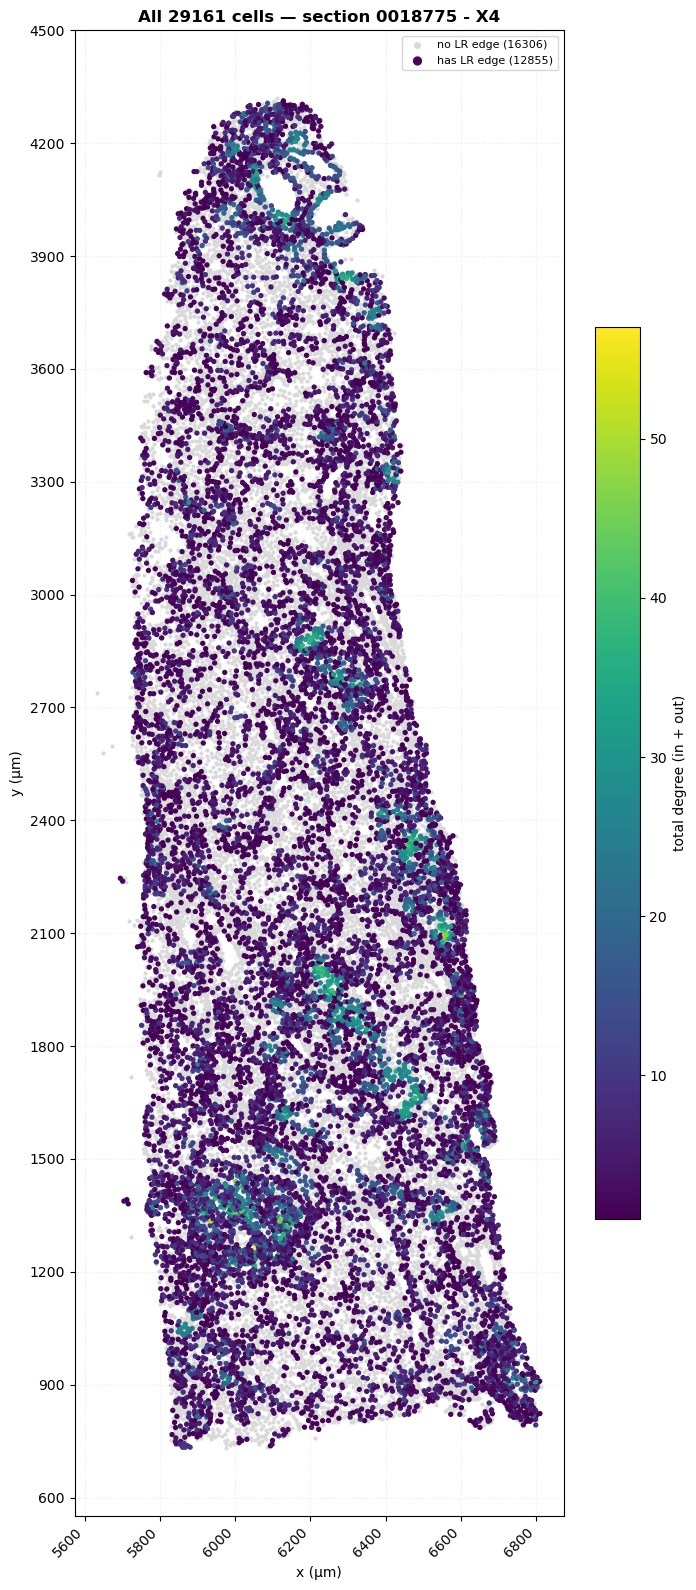

x range: 5632.6 .. 6813.9
y range: 731.1 .. 4320.6


In [105]:
# 10a. Overview: every cell of the section as a point in the XY plane.
# Read the axes to choose the window you want to zoom into in the next cell.

# Build the graph on the FULL section (no max_cells cap) so a crop shows complete
# connectivity. ~2 s for ~29k cells.
g_full = build_cellnest_graph(sub, lr, spatial_key="spatial", d_max=30.0,
                              gene_activity_percentile=98.0,
                              block_autocrine=True)   # paracrine only
print(f"full-section graph: {g_full.n_nodes} cells, {g_full.n_edges} directed LR edges")

xy = g_full.coordinates
x, y = xy[:, 0], xy[:, 1]

# Degree tells you where the signalling actually is, so the overview is useful for choosing.
deg = (np.bincount(g_full.edge_index[0], minlength=g_full.n_nodes) +
       np.bincount(g_full.edge_index[1], minlength=g_full.n_nodes))

# Shape the figure like the tissue (aspect is equal, so a square figure would waste space).
aspect = (y.max() - y.min()) / max(x.max() - x.min(), 1e-9)
fig, ax = plt.subplots(figsize=(7, float(np.clip(7 * aspect, 5, 16))))

ax.scatter(x[deg == 0], y[deg == 0], s=4, c="#d9d9d9", label=f"no LR edge ({int((deg==0).sum())})")
pts = ax.scatter(x[deg > 0], y[deg > 0], s=8, c=deg[deg > 0], cmap="viridis",
                 label=f"has LR edge ({int((deg>0).sum())})")
plt.colorbar(pts, ax=ax, label="total degree (in + out)", shrink=0.6)

ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.set_title(f"All {g_full.n_nodes} cells — section {sub.obs['Biopsy_ID'].iloc[0]}",
             fontweight="bold")
ax.set_aspect("equal")
ax.grid(True, which="both", alpha=0.25, linestyle=":")
ax.legend(loc="upper right", fontsize=8, markerscale=2)

# Dense ticks so coordinate values are easy to read off for the zoom.
ax.xaxis.set_major_locator(plt.MaxNLocator(8))
ax.yaxis.set_major_locator(plt.MaxNLocator(14))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout(); plt.show()

print(f"x range: {x.min():.1f} .. {x.max():.1f}")
print(f"y range: {y.min():.1f} .. {y.max():.1f}")

window x=(5900, 6100), y=(900, 1100)
cells inside      : 413
edges fully inside: 529
edges crossing the boundary: 126 (drawn — set INCLUDE_CROSSING to toggle)
edges drawn       : 655


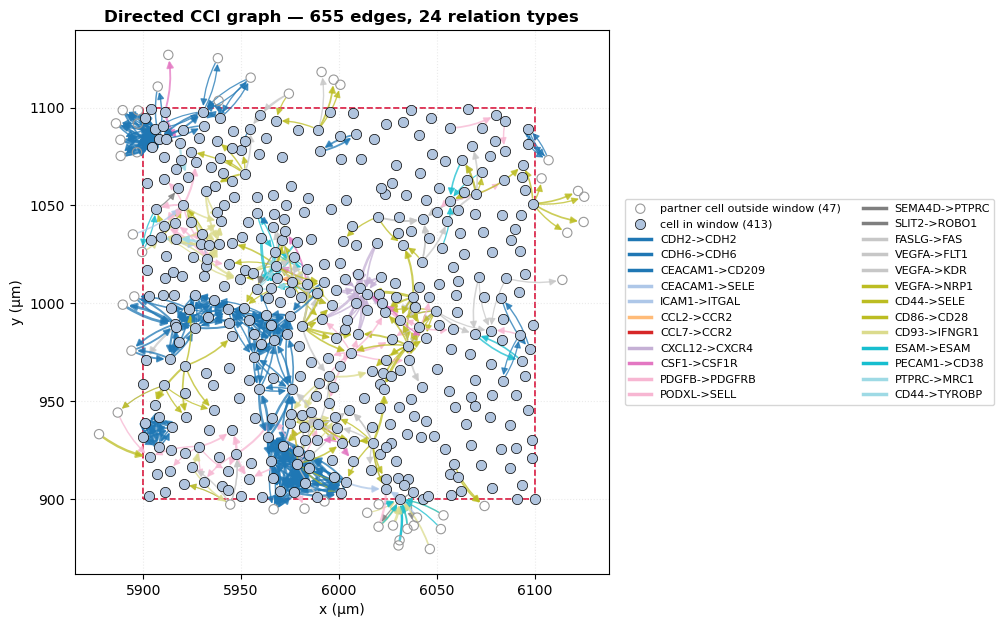


top relations in this window:
ligand  receptor
CDH6    CDH6        302
VEGFA   NRP1         98
PDGFB   PDGFRB       48
CD93    IFNGR1       42
VEGFA   FLT1         37
        KDR          31
CXCL12  CXCR4        21
PECAM1  CD38         16
CSF1    CSF1R        10
CDH2    CDH2         10


In [107]:
# 10b. Zoom: pick a window from the plot above and see every directed CCI edge in it.
# ----------------------------------------------------------------------------- EDIT THESE
X_RANGE = (5900, 6100)      # (xmin, xmax) in the same µm units as the axes above
Y_RANGE = (900, 1100)       # (ymin, ymax)
INCLUDE_CROSSING = True     # also draw edges with only ONE endpoint inside the window
# -----------------------------------------------------------------------------------------

xy = g_full.coordinates
inside = ((xy[:, 0] >= X_RANGE[0]) & (xy[:, 0] <= X_RANGE[1]) &
          (xy[:, 1] >= Y_RANGE[0]) & (xy[:, 1] <= Y_RANGE[1]))
n_inside = int(inside.sum())
if n_inside == 0:
    raise ValueError(f"No cells in x={X_RANGE}, y={Y_RANGE}. Widen the window "
                     f"(section spans x {xy[:,0].min():.0f}..{xy[:,0].max():.0f}, "
                     f"y {xy[:,1].min():.0f}..{xy[:,1].max():.0f}).")

src, dst = g_full.edge_index[0], g_full.edge_index[1]
both = inside[src] & inside[dst]
either = inside[src] | inside[dst]
keep = either if INCLUDE_CROSSING else both
sel = np.nonzero(keep)[0]
n_crossing = int(either.sum() - both.sum())

print(f"window x={X_RANGE}, y={Y_RANGE}")
print(f"cells inside      : {n_inside}")
print(f"edges fully inside: {int(both.sum())}")
print(f"edges crossing the boundary: {n_crossing} "
      f"({'drawn' if INCLUDE_CROSSING else 'hidden'} — set INCLUDE_CROSSING to toggle)")
print(f"edges drawn       : {sel.size}")

# Relation colours, stable across the notebook
rel_colors_full = plt.cm.tab20(np.linspace(0, 1, max(g_full.n_relations, 1)))

fig, ax = plt.subplots(figsize=(10, 10))

# Cells: inside the window solid, partners just outside it hollow (they explain crossing edges)
partner = np.zeros(g_full.n_nodes, dtype=bool)
if INCLUDE_CROSSING and sel.size:
    partner[src[sel]] = True
    partner[dst[sel]] = True
partner &= ~inside
if partner.any():
    ax.scatter(xy[partner, 0], xy[partner, 1], s=45, facecolors="none",
               edgecolors="#999999", linewidths=0.8, zorder=3,
               label=f"partner cell outside window ({int(partner.sum())})")
ax.scatter(xy[inside, 0], xy[inside, 1], s=55, c="lightsteelblue",
           edgecolors="k", linewidths=0.5, zorder=4, label=f"cell in window ({n_inside})")

# Directed edges, coloured by relation type, width by co-expression strength
coexp = g_full.edge_feature("coexpression_score")
cmax = float(coexp[sel].max()) if sel.size else 1.0
for k in sel:
    i, j = int(src[k]), int(dst[k])
    x0, y0 = xy[i, 0], xy[i, 1]
    x1, y1 = xy[j, 0], xy[j, 1]
    lw = 0.6 + (float(coexp[k]) / cmax) * 2.2 if cmax > 0 else 0.6
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=rel_colors_full[int(g_full.edge_relation_id[k])],
                                lw=lw, alpha=0.75, shrinkA=4, shrinkB=4,
                                connectionstyle="arc3,rad=0.12"), zorder=2)

# Draw the requested window so crossing edges are readable
ax.add_patch(plt.Rectangle((X_RANGE[0], Y_RANGE[0]),
                           X_RANGE[1] - X_RANGE[0], Y_RANGE[1] - Y_RANGE[0],
                           fill=False, edgecolor="crimson", linestyle="--", lw=1.2, zorder=1))

# Legend: cells, then only the relation types actually present in this window
used = sorted({int(r) for r in g_full.edge_relation_id[sel]})
rel_handles = [plt.Line2D([0], [0], color=rel_colors_full[i], lw=2.5,
                          label=f"{g_full.relation_table.iloc[i].ligand}"
                                f"->{g_full.relation_table.iloc[i].receptor}")
               for i in used]
cell_handles, cell_labels = ax.get_legend_handles_labels()
ax.legend(handles=cell_handles + rel_handles, fontsize=8, ncol=2,
          loc="center left", bbox_to_anchor=(1.02, 0.5))

ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.set_title(f"Directed CCI graph — {sel.size} edges, {len(used)} relation types",
             fontweight="bold")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25, linestyle=":")
plt.tight_layout(); plt.show()

# Which signalling dominates this window?
win = g_full.edge_table.iloc[sel]
print("\ntop relations in this window:")
print(win.groupby(["ligand", "receptor"]).size()
         .sort_values(ascending=False).head(10).to_string())